In [1]:
import pandas as pd

df = pd.read_csv('../data/House_Prices.csv')

### Information About Data

In [2]:
# check our datatypes
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   str    
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2919 non-null   str    
 8   LandContour    2919 non-null   str    
 9   Utilities      2917 non-null   str    
 10  LotConfig      2919 non-null   str    
 11  LandSlope      2919 non-null   str    
 12  Neighborhood   2919 non-null   str    
 13  Condition1     2919 non-null   str    
 14  Condition2     2919 non-null   str    
 15  BldgType       2919 non-null   str    
 16  HouseStyle     2919 non-null   str    
 17  OverallQual    2919 non-null   int64  
 18  OverallCond    2919

In [3]:
# Missing values: only columns that have some, sorted
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageQual       159
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
Functional         2
BsmtHalfBath       2
Utilities          2
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
KitchenQual        1
GarageArea         1
GarageCars         1
SaleType           1
dtype: int64


In [4]:
print(df.shape)
print(df["SalePrice"].isna().sum())
print(df.duplicated().sum())
print(df["SalePrice"].describe())

(2919, 81)
0
0
count      2919.000000
mean     180052.854647
std       57381.565721
min       34900.000000
25%      154795.084126
50%      176734.841494
75%      191895.744157
max      755000.000000
Name: SalePrice, dtype: float64


In [5]:
print((df["SalePrice"] % 1 != 0).sum())   # rows with non-whole prices
print(df["Id"].min(), df["Id"].max())

1459
1 2919


In [6]:
df = df[df["Id"] <= 1460].copy()
print(df.shape)
print(df["SalePrice"].describe())

(1460, 81)
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [7]:
print((df["YearRemodAdd"] < df["YearBuilt"]).sum())   # remodeled before being built?
print((df["YrSold"] < df["YearBuilt"]).sum())         # sold before being built?
print((df["GarageYrBlt"] > df["YrSold"]).sum())       # garage built after the sale?
print((df["GarageYrBlt"] > 2010).sum())               # impossible future years?

0
0
0
0


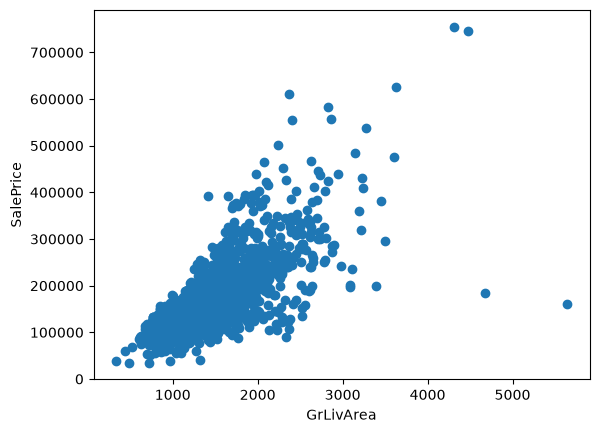

        Id  GrLivArea  SalePrice
523    524       4676   184750.0
691    692       4316   755000.0
1182  1183       4476   745000.0
1298  1299       5642   160000.0


In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

print(df[df["GrLivArea"] > 4000][["Id", "GrLivArea", "SalePrice"]])

In [9]:
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000))]
print(df.shape)   # (1458, 81)

(1458, 81)


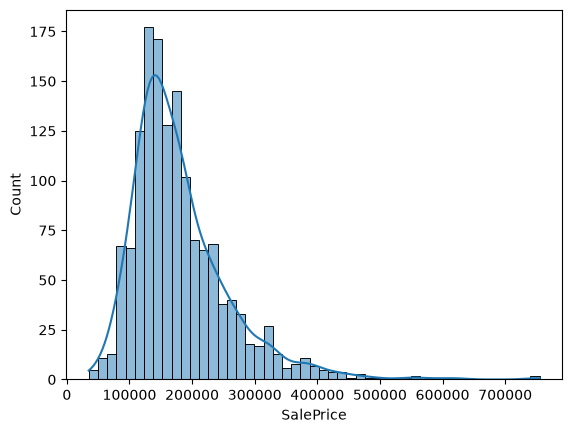

1.8812964895244009


In [10]:
import seaborn as sns

sns.histplot(df["SalePrice"], kde=True)
plt.show()

print(df["SalePrice"].skew())

In [11]:
# Kind 1: NaN means "doesn't have it" -> fill with the text "None"
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "MasVnrType",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
]
df[none_cols] = df[none_cols].fillna("None")

# Kind 2: NaN means "0 of it" -> fill with 0
zero_cols = [
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea",
]
df[zero_cols] = df[zero_cols].fillna(0)

# MSSubClass is a code for a category, not a real number
df["MSSubClass"] = df["MSSubClass"].astype(str)

In [12]:
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

LotFrontage    259
GarageYrBlt     81
Electrical       1
dtype: int64


In [13]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["TotalBath"] = (df["FullBath"] + 0.5 * df["HalfBath"]
                   + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"])
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["YearsSinceRemod"] = df["YrSold"] - df["YearRemodAdd"]

In [14]:
y = df["SalePrice"]
X = df.drop(columns=["SalePrice", "Id"])
print(X.shape, y.shape)   # (1458, 79) (1458,)

(1458, 83) (1458,)


In [15]:
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
print(len(num_cols), len(cat_cols))

39 44


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(1166, 83) (292, 83)


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
# for unknow category all column got zeros
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'HouseAge', 'YearsSinceRemod']


In [18]:
X_train_prep = preprocessor.fit_transform(X_train)   # learns medians, scales, categories
X_test_prep = preprocessor.transform(X_test)         # only applies them

print(X_train_prep.shape, X_test_prep.shape)

(1166, 316) (292, 316)


In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train = X_train.copy()
train["SalePrice"] = y_train

### Explanation for the code below
$$\text{Price} = \$100,000 \longrightarrow \log(1 + 100,000) \approx 11.51$$$$\text{Price} = \$750,000 \longrightarrow \log(1 + 750,000) \approx 13.52$$

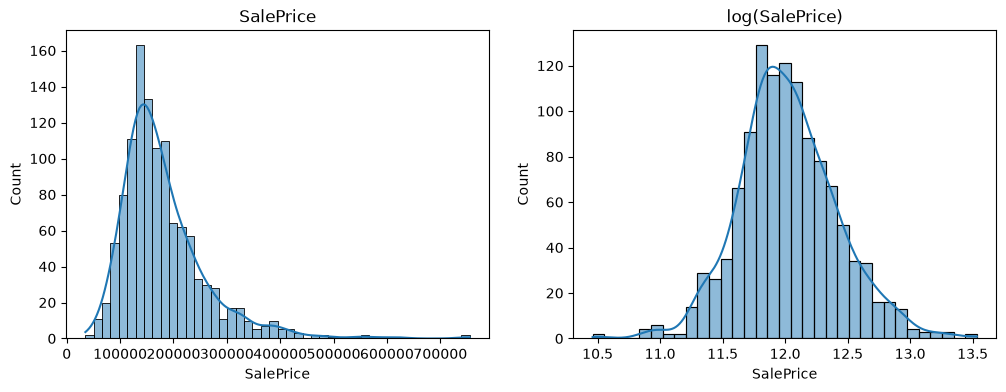

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=ax[0])
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=ax[1])
ax[0].set_title("SalePrice")
ax[1].set_title("log(SalePrice)")
plt.show()

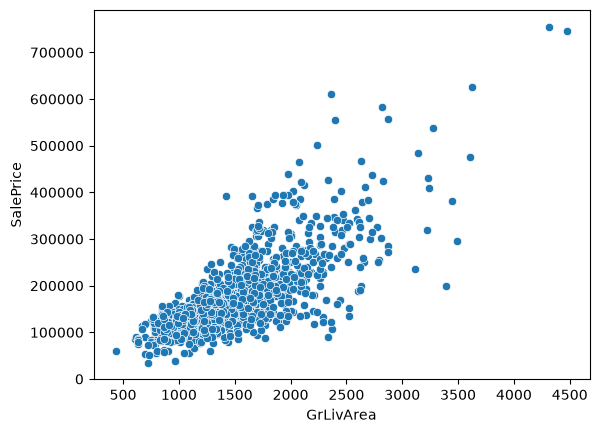

In [21]:
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice")
plt.show()

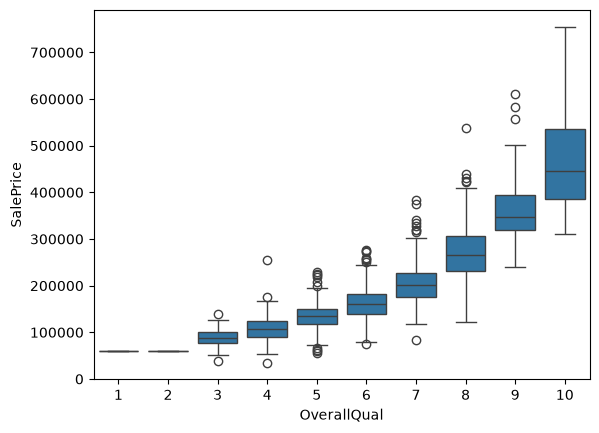

In [22]:
sns.boxplot(data=train, x="OverallQual", y="SalePrice")
plt.show()

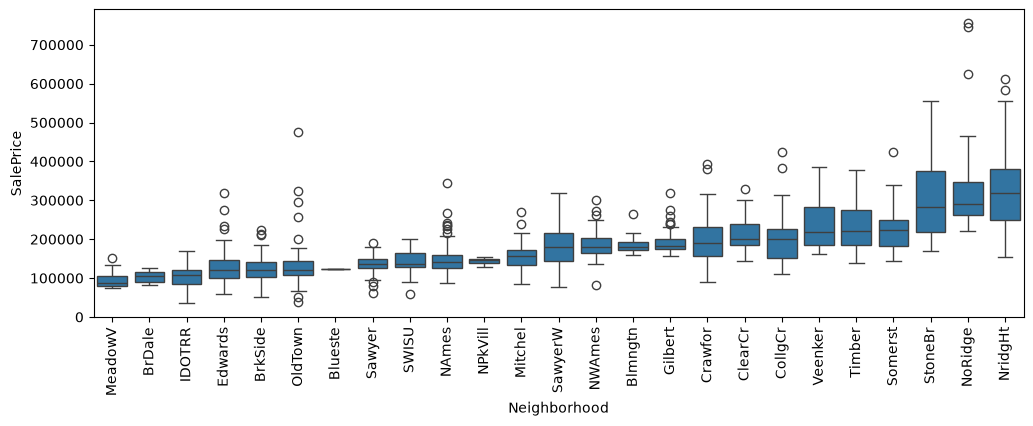

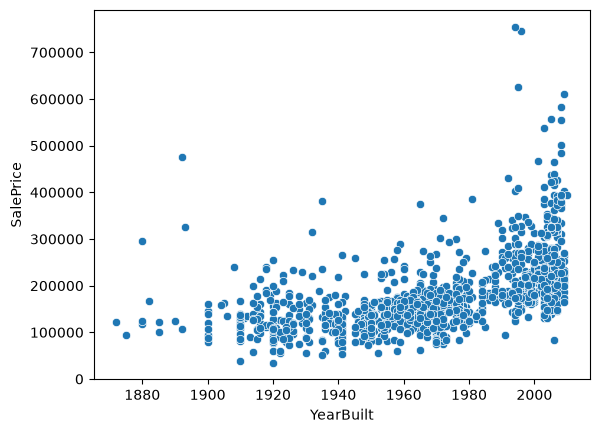

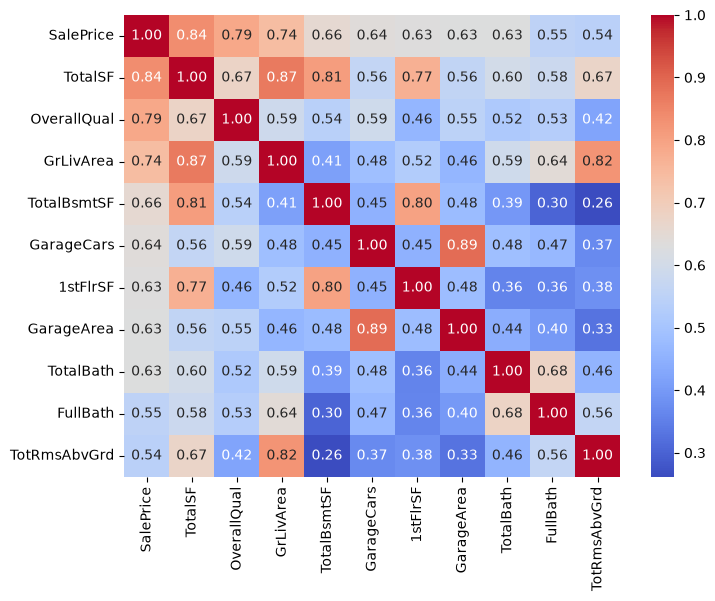

In [23]:
# Chart 4: price by neighborhood, sorted by median price
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
plt.figure(figsize=(12, 4))
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order)
plt.xticks(rotation=90)
plt.show()

# Chart 5: year built vs price
sns.scatterplot(data=train, x="YearBuilt", y="SalePrice")
plt.show()

# Chart 6: the 10 numeric features most correlated with price
corr = train.select_dtypes(include="number").corr()
top = corr["SalePrice"].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(8, 6))
sns.heatmap(train[top].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

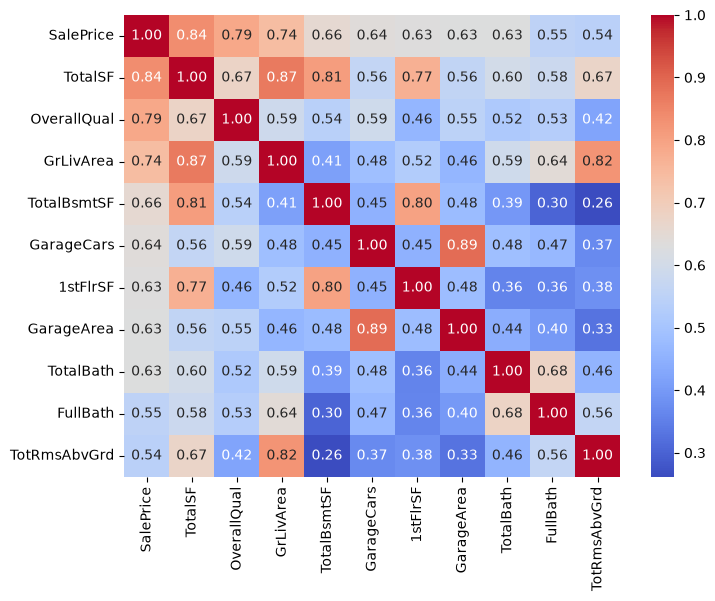

Index(['SalePrice', 'TotalSF', 'OverallQual', 'GrLivArea', 'TotalBsmtSF',
       'GarageCars', '1stFlrSF', 'GarageArea', 'TotalBath', 'FullBath',
       'TotRmsAbvGrd'],
      dtype='str')


In [32]:
# # 1. Drop redundant Garage feature
# train = train.drop(columns=["GarageArea"])

# # 2. Create composite TotalSF feature
# train["TotalSF"] = (
#     train["1stFlrSF"].fillna(0) + 
#     train["2ndFlrSF"].fillna(0) + 
#     train["TotalBsmtSF"].fillna(0)
# )

# # 3. Drop individual floor columns to prevent redundancy with TotalSF
# train = train.drop(columns=["1stFlrSF", "2ndFlrSF", "TotalBsmtSF"])

# Chart 6: the 10 numeric features most correlated with price
corr = train.select_dtypes(include="number").corr()
top = corr["SalePrice"].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(8, 6))
sns.heatmap(train[top].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()
print(top)

In [25]:
new = ["TotalSF", "TotalBath", "HouseAge", "YearsSinceRemod"]
print(df[new].describe())
print(df[new + ["SalePrice"]].corr()["SalePrice"])

           TotalSF    TotalBath     HouseAge  YearsSinceRemod
count  1458.000000  1458.000000  1458.000000      1458.000000
mean   2557.150206     2.207476    36.598080        22.982167
std     774.109803     0.781341    30.240565        20.636501
min     334.000000     1.000000     0.000000         0.000000
25%    2008.500000     2.000000     8.000000         4.000000
50%    2473.000000     2.000000    35.000000        14.000000
75%    3002.250000     2.500000    54.000000        41.000000
max    6872.000000     6.000000   136.000000        60.000000
TotalSF            0.832877
TotalBath          0.635896
HouseAge          -0.524067
YearsSinceRemod   -0.509706
SalePrice          1.000000
Name: SalePrice, dtype: float64


In [31]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Ridge": Ridge(alpha=10),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "SVR": SVR(C=10, epsilon=0.05),
}

results = []
for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=model, func=np.log1p, inverse_func=np.expm1)),
    ])
    pipe.fit(X_train, y_train)          # learns from training data only
    pred = pipe.predict(X_test)         # predictions in dollars

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })

pd.DataFrame(results).round(3)

,Model,MAE,RMSE,R2
0,Ridge,14295.266,20004.720,0.928
1,RandomForest,16324.438,23544.502,0.900
2,SVR,15492.281,22024.617,0.912


In [34]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=model, func=np.log1p, inverse_func=np.expm1)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")
    print(name, scores.round(3), "mean:", scores.mean().round(3), "std:", scores.std().round(3))

Ridge [0.932 0.947 0.948 0.924 0.931] mean: 0.937 std: 0.01
RandomForest [0.891 0.892 0.883 0.884 0.876] mean: 0.885 std: 0.006
SVR [0.879 0.686 0.846 0.892 0.851] mean: 0.831 std: 0.074


In [36]:
from sklearn.model_selection import GridSearchCV

# Ridge: only one hyperparameter to search
ridge_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=Ridge(), func=np.log1p, inverse_func=np.expm1)),
])
ridge_grid = {"model__regressor__alpha": [0.1, 1, 10, 30, 50, 100]}

ridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=kf, scoring="r2", n_jobs=-1)
ridge_search.fit(X_train, y_train)
print("Ridge best alpha:", ridge_search.best_params_, "best R2:", ridge_search.best_score_.round(3))

Ridge best alpha: {'model__regressor__alpha': 10} best R2: 0.937


In [37]:
# SVR: 3 hyperparameters, small grid to keep it fast
svr_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=SVR(), func=np.log1p, inverse_func=np.expm1)),
])
svr_grid = {
    "model__regressor__C": [1, 10, 50],
    "model__regressor__epsilon": [0.01, 0.05, 0.1],
    "model__regressor__kernel": ["rbf", "linear"],
}

svr_search = GridSearchCV(svr_pipe, svr_grid, cv=kf, scoring="r2", n_jobs=-1)
svr_search.fit(X_train, y_train)
print("SVR best params:", svr_search.best_params_, "best R2:", svr_search.best_score_.round(3))

SVR best params: {'model__regressor__C': 1, 'model__regressor__epsilon': 0.01, 'model__regressor__kernel': 'linear'} best R2: 0.926


In [39]:
final_models = {
    "Ridge (tuned)": ridge_search.best_estimator_,
    "SVR (tuned)": svr_search.best_estimator_,
    "RandomForest": Pipeline([
        ("prep", preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
            func=np.log1p, inverse_func=np.expm1)),
    ]),
}

final_results = []
preds = {}
for name, pipe in final_models.items():
    if name == "RandomForest":
        pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    preds[name] = pred
    final_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })

pd.DataFrame(final_results).round(3)

,Model,MAE,RMSE,R2
0,Ridge (tuned),14295.266,20004.720,0.928
1,SVR (tuned),14639.112,21003.100,0.920
2,RandomForest,16324.438,23544.502,0.900


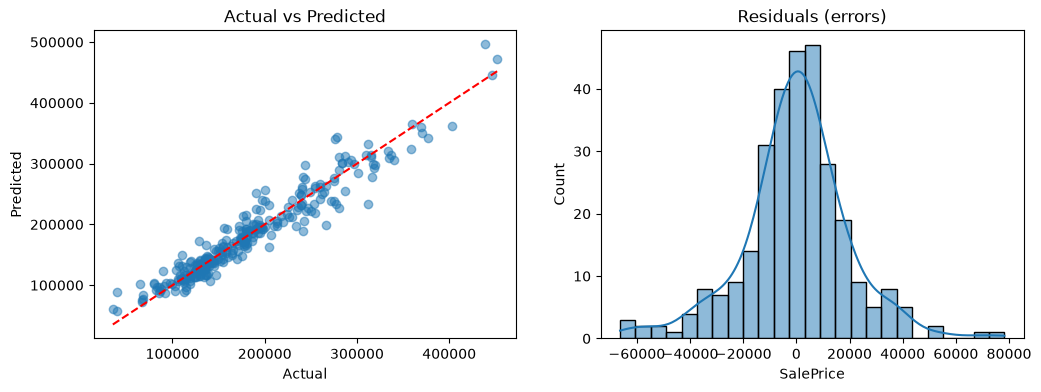

In [40]:
best_name = "Ridge (tuned)"   # adjust if your table says otherwise
best_pred = preds[best_name]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
"""
Your chart reading is exactly right and it's an important,
common pattern: tight fit at low prices, looser at high prices.
This matches what you noticed back in the quality-vs-price boxplot
(bigger boxes at high quality)
"""
ax[0].scatter(y_test, best_pred, alpha=0.5)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
ax[0].set_title("Actual vs Predicted")

residuals = y_test - best_pred
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Residuals (errors)")
plt.show()

In [42]:
error_df = X_test.copy()
error_df["Actual"] = y_test
error_df["Predicted"] = best_pred
error_df["AbsError"] = (error_df["Actual"] - error_df["Predicted"]).abs()

worst = error_df.sort_values("AbsError", ascending=False).head(10)
print(worst[["Actual", "Predicted", "AbsError", "OverallQual", "GrLivArea", "Neighborhood", "TotalSF"]])

        Actual      Predicted      AbsError  OverallQual  GrLivArea  \
218   311500.0  233248.679546  78251.320454            7       1954   
747   265979.0  198491.088165  67487.911835            7       2640   
1044  278000.0  344288.011585  66288.011585            8       2524   
261   276000.0  341106.817473  65106.817473            8       2574   
1440  191000.0  251818.286207  60818.286207            6       2555   
58    438780.0  495980.645921  57200.645921           10       2945   
529   200624.0  256640.250900  56016.250900            6       2515   
70    244000.0  298034.418463  54034.418463            7       2223   
271   241500.0  188468.156962  53031.843038            7       1363   
451   280000.0  227174.635201  52825.364799            7       1533   

     Neighborhood  TotalSF  
218       Crawfor   2752.0  
747       OldTown   3880.0  
1044       NWAmes   5048.0  
261       CollgCr   4056.0  
1440      Crawfor   2759.0  
58        StoneBr   4355.0  
529       Crawf